---
title: "Lab 3: Estadistica Descriptiva 2"
author: "Maximiliano Garnier Villarreal"
---

# Paquetes

In [ ]:
import pandas as pd
import polars as pl
import polars.selectors as cs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import plotly.express as px
import statistics
from scipy import stats

from great_tables.data import airquality

p9.theme_set(p9.theme_bw())

# Estadistica descriptiva bivariable

Vamos a usar los datos de `airquality`. Vamos a crear variables centradas y estandarizadas (z-scores) para las variables numericas.

In [2]:
#| label: datos
#| tbl-cap: Datos de airquality modificados

airq = pl.from_pandas(airquality).with_columns(
  pl.col("Month","Day").
  cast(pl.String).
  cast(pl.Categorical)
  )

num_cols = airq.select(cs.numeric()).columns

exprs_c = [ (pl.col(c) - pl.col(c).mean()).alias(f"{c}_c") for c in num_cols ]
exprs_z = [ ((pl.col(c) - pl.col(c).mean()) / pl.col(c).std()).alias(f"{c}_z") for c in num_cols ]

airq = airq.with_columns(*(exprs_c + exprs_z))
airq

Ozone,Solar_R,Wind,Temp,Month,Day,Ozone_c,Solar_R_c,Wind_c,Temp_c,Ozone_z,Solar_R_z,Wind_z,Temp_z
f64,f64,f64,i64,cat,cat,f64,f64,f64,f64,f64,f64,f64,f64
41.0,190.0,7.4,67,"""5""","""1""",-1.12931,4.068493,-2.557516,-10.882353,-0.034234,0.045176,-0.725948,-1.149714
36.0,118.0,8.0,72,"""5""","""2""",-6.12931,-67.931507,-1.957516,-5.882353,-0.185805,-0.754305,-0.555639,-0.621467
12.0,149.0,12.6,74,"""5""","""3""",-30.12931,-36.931507,2.642484,-3.882353,-0.913345,-0.410084,0.750066,-0.410168
18.0,313.0,11.5,62,"""5""","""4""",-24.12931,127.068493,1.542484,-15.882353,-0.73146,1.410956,0.437832,-1.677961
null,null,14.3,56,"""5""","""5""",null,null,4.342484,-21.882353,null,null,1.232609,-2.311857
…,…,…,…,…,…,…,…,…,…,…,…,…,…
30.0,193.0,6.9,70,"""9""","""26""",-12.12931,7.068493,-3.057516,-7.882353,-0.36769,0.078488,-0.867873,-0.832766
null,145.0,13.2,77,"""9""","""27""",null,-40.931507,3.242484,-0.882353,null,-0.454499,0.920375,-0.09322
14.0,191.0,14.3,75,"""9""","""28""",-28.12931,5.068493,4.342484,-2.882353,-0.852716,0.05628,1.232609,-0.304519


Otra forma de crear las variables estandarizadas y centradas es usando `map_batches`, con la funcion `stats.zscore` de **scipy** para los z-scores y una funcion lambda para las variables centradas.

In [3]:
pl.from_pandas(airquality).with_columns(
  pl.col("Month","Day").
  cast(pl.String).
  cast(pl.Categorical)
  ).with_columns(
    cs.numeric().
    map_batches(lambda x: (x - x.mean()) / x.std()).name.suffix("_z"),
    # map_batches(lambda x: stats.zscore(x, ddof=1, nan_policy="omit")).name.suffix("_z"),
    cs.numeric().
    map_batches(lambda x: (x - x.mean())).name.suffix("_c")
  )

Ozone,Solar_R,Wind,Temp,Month,Day,Ozone_z,Solar_R_z,Wind_z,Temp_z,Ozone_c,Solar_R_c,Wind_c,Temp_c
f64,f64,f64,i64,cat,cat,f64,f64,f64,f64,f64,f64,f64,f64
41.0,190.0,7.4,67,"""5""","""1""",-0.034234,0.045176,-0.725948,-1.149714,-1.12931,4.068493,-2.557516,-10.882353
36.0,118.0,8.0,72,"""5""","""2""",-0.185805,-0.754305,-0.555639,-0.621467,-6.12931,-67.931507,-1.957516,-5.882353
12.0,149.0,12.6,74,"""5""","""3""",-0.913345,-0.410084,0.750066,-0.410168,-30.12931,-36.931507,2.642484,-3.882353
18.0,313.0,11.5,62,"""5""","""4""",-0.73146,1.410956,0.437832,-1.677961,-24.12931,127.068493,1.542484,-15.882353
null,null,14.3,56,"""5""","""5""",null,null,1.232609,-2.311857,null,null,4.342484,-21.882353
…,…,…,…,…,…,…,…,…,…,…,…,…,…
30.0,193.0,6.9,70,"""9""","""26""",-0.36769,0.078488,-0.867873,-0.832766,-12.12931,7.068493,-3.057516,-7.882353
null,145.0,13.2,77,"""9""","""27""",null,-0.454499,0.920375,-0.09322,null,-40.931507,3.242484,-0.882353
14.0,191.0,14.3,75,"""9""","""28""",-0.852716,0.05628,1.232609,-0.304519,-28.12931,5.068493,4.342484,-2.882353


Se seleccionan las variables numericas excluyendo las columnas con sufijos `_c` y `_z`.

In [7]:
airq2 = airq.select(cs.numeric() & ~cs.ends_with(['_c','_z']))
airq2_pd = airq2.to_pandas()

## Covarianza & Correlacion

Dentro de las funciones para calcular covarianza y correlacion entre variables en **Python** se encuentran:

- `stats.pearsonr(x, y)`: arroja el coeficiente de correlacion de Pearson y el p-valor asociado.
- `np.corrcoef(x, y)`: arroja la matriz de correlacion de Pearson .
- `np.cov(x, y)`: arroja la matriz de covarianza.
- `statistics.correlation(x, y)`: arroja el coeficiente de correlacion de Pearson.
- `pg.corr(x, y)`: arroja el coeficiente de correlacion de Pearson, Spearman o Kendall, así como resultados adicionales.

Aqui se extraen las variables de interes:

In [5]:
pair = airq.drop_nulls(subset=["Solar_R", "Temp"])

x = pair["Solar_R"].to_numpy().ravel()
y = pair["Temp"].to_numpy().ravel()

print(stats.pearsonr(x, y))

PearsonRResult(statistic=np.float64(0.27584027134080463), pvalue=np.float64(0.000751772924010308))

In [ ]:
print(np.corrcoef(x, y)[0, 1])

In [ ]:
print(statistics.correlation(x, y))

Matrices de correlacion y covarianza del DataFrame con unicamente variables numericas. Es necesario eliminar los valores faltantes (`dropna()`).

In [ ]:
print(airq2_pd.dropna().cov())  # matriz de varianza-covarianza

In [ ]:
print(airq2_pd.dropna().corr()) # matriz de correlacion de Pearson

Grafico de correlacion

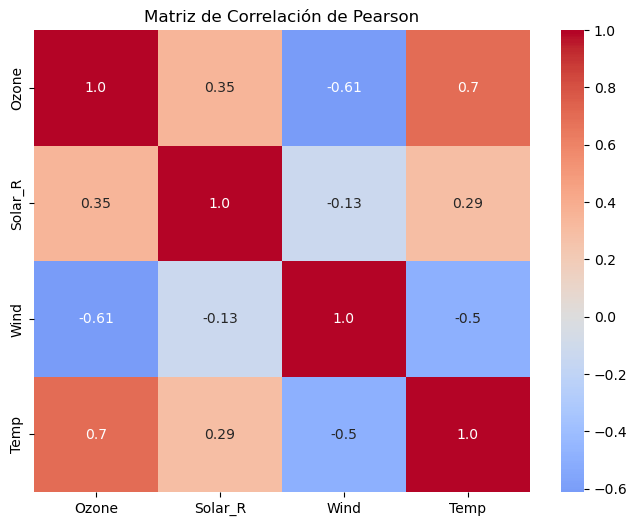

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(airq2_pd.dropna().corr(), annot=True, fmt=".2", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación de Pearson")
plt.show()

In [ ]:
fig = px.imshow(airq2_pd.dropna().corr(), 
                color_continuous_scale=px.colors.diverging.RdBu_r,
                title='Matriz de Correlación de Pearson')
fig.show()

## Regresion

Necesitamos importar funciones de statsmodels para ajustar modelos de regresion lineal y polinomial, y para evaluar su ajuste.

In [9]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tools.eval_measures import rmse
from statsmodels.stats.anova import anova_lm

Dentro de las funciones para realizar regresiones en **Python** se encuentran:

- `smf.ols(formula, data)`: ajusta un modelo de regresion lineal usando una formula similar a **R**.
- `sm.OLS(endog/y, exog/x)`: ajusta un modelo de regresion lineal usando matrices numpy o pandas.
  - `fit()`: metodo para ajustar el modelo.
    - `summary()`: metodo para obtener un resumen del ajuste del modelo.
- `anova_lm(mod1, mod2)`: funcion para comparar modelos anidados usando un analisis de varianza.
- `rmse(predicted, actual)`: funcion para calcular el error cuadratico medio entre valores predichos y reales.

- `stats.linregress(x, y)`: funcion para ajustar una regresion lineal simple, obteniendo coeficientes y estadisticos asociados.
- `np.polyfit(x, y, deg)`: funcion para ajustar una regresion polinomial de grado `deg`, obteniendo solo coeficientes.
- `statistics.linear_regression(x, y)`: solo coeficientes de regresion lineal.
- `pg.linear_regression(x, y)`: coeficientes de regresion lineal y estadisticos asociados.


### Relacion entre correlacion y regresion simple

En una regresion simple ($y \sim x$, un predictor) el coeficiente de correlacion (y covarianza) entre ambas variables va a ser igual a la pendiente de la regresion cuando se usan variables estandarizadas ($z \sim N(0,1)$).

Usando variables estandarizadas:

In [ ]:
coefs = np.polyfit(x=airq["Wind_z"], y=airq["Temp_z"], deg=1)
print(coefs)

Correlacion y covarianza entre variables estandarizadas:

In [ ]:
print(np.corrcoef(airq["Wind_z"], airq["Temp_z"])[0, 1])

In [ ]:
print(np.cov(airq["Wind_z"], airq["Temp_z"])[0, 1])

### Lineal

$y \thicksim \hat{b}_0 + \hat{b}_1x + \epsilon$

In [10]:
mod1 = smf.ols('Temp ~ Solar_R', data=airquality).fit()  # modelo de regresion lineal

Coeficientes del modelo

In [11]:
# mod1.summary().tables[1]
mod1.params
# mod1.get_prediction().summary_frame(alpha=0.05)
mod1_params = pd.DataFrame({
    'Predictor': mod1.params.index,
    'Estimate': mod1.params.values
})
mod1_params

,Predictor,Estimate
0,Intercept,72.863012
1,Solar_R,0.028255


Ajuste del modelo

In [12]:
# mod1.summary().tables[0]
print(rmse(mod1.fittedvalues, mod1.model.endog))  # RMSE

8.836479083280576


In [14]:
print(mod1.rsquared)  # R^2

0.07608785529336892


In [ ]:
print(mod1.rsquared_adj)  # R^2 ajustado

In [ ]:
print(mod1.aic)  # AIC

### Cuadratica

$y \thicksim \hat{b}_0 + \hat{b}_1x + \hat{b}_2x^2 + \epsilon$

In [16]:
mod2 = smf.ols('Temp ~ Solar_R + I(Solar_R**2)', data=airquality).fit() # modelo de regresion cuadratica

Coeficientes del modelo

In [17]:
mod2.params

Intercept          64.267729
Solar_R             0.175813
I(Solar_R ** 2)    -0.000442
dtype: float64

Ajuste del modelo

In [ ]:
# mod2.summary().tables[0]
print(rmse(mod2.fittedvalues, mod2.model.endog))  # RMSE

In [18]:
print(mod2.rsquared)  # R^2

0.2026903248315638


In [ ]:
print(mod2.rsquared_adj)  # R^2 ajustado

In [ ]:
print(mod2.aic)  # AIC

### Compara modelos

In [19]:
anova_lm(mod1, mod2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,144.0,11400.170938,0.0,NaN,NaN,NaN
1,143.0,9838.020465,1.0,1562.150473,22.706551,0.000005


## Graficos

Para agregar lineas de tendencia en graficos de **plotnine** se usa la funcion `geom_smooth`. Por defecto ajusta una curva loess, pero para cambiarlo se usa `method = 'lm'`, y para especificar una ecuacion diferente a la regresion simple se usa `formula`, donde `y` y `x` son genericos, **NO** hay que poner el nombre de las variables que se esta graficando.

En **seaborn** se usa la funcion `regplot`, donde el argumento `order` define el grado del polinomio a ajustar (1 = lineal, 2 = cuadratico, etc).

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 7 rows containing missing values.


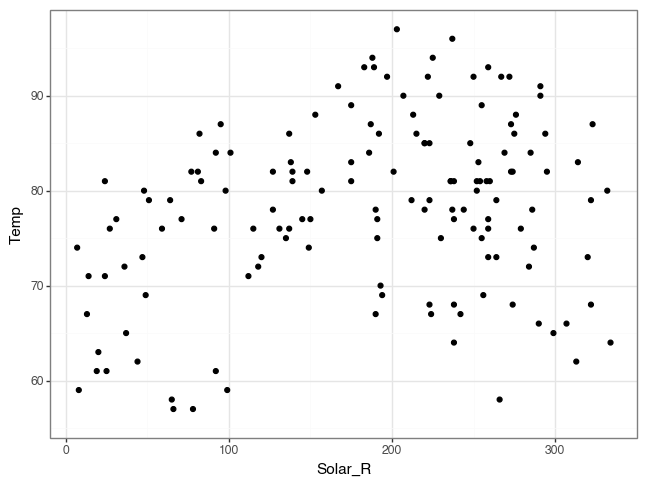

In [20]:
(p9.ggplot(airq, p9.aes("Solar_R","Temp")) + 
  p9.geom_point())

In [ ]:
(p9.ggplot(airq, p9.aes("Solar_R","Temp")) + 
  p9.geom_point() + 
  p9.geom_smooth(color='blue'))

Grafico de regresion lineal

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 7 rows containing missing values.


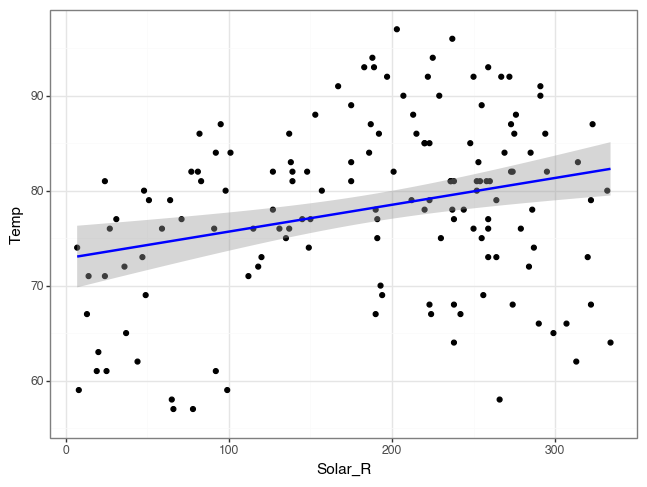

In [21]:
(p9.ggplot(airq, p9.aes("Solar_R","Temp")) + 
  p9.geom_point() + 
  p9.geom_smooth(method = 'lm',color='blue')) 

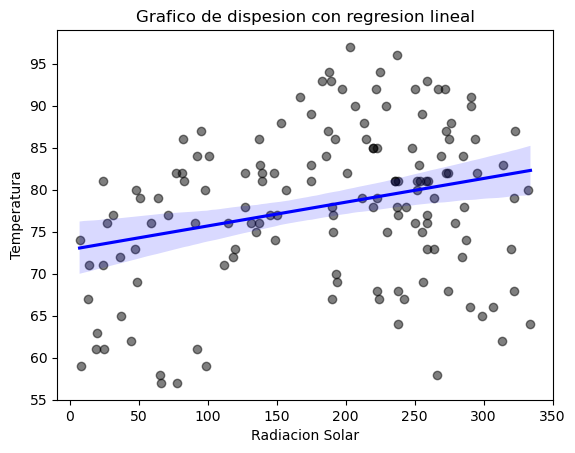

In [22]:
fig, ax = plt.subplots()
sns.regplot(data=airq, x="Solar_R", y="Temp", order=1,
            scatter_kws={'alpha':0.5, 'color':'black'},
            line_kws={'color':'blue'})
plt.xlabel("Radiacion Solar")
plt.ylabel("Temperatura")
plt.title("Grafico de dispesion con regresion lineal")
plt.show()

Grafico de regresion cuadratica

In [ ]:
(p9.ggplot(airq, p9.aes("Solar_R","Temp")) + 
  p9.geom_point() + 
  p9.geom_smooth(method = 'lm',color='blue', 
                formula = 'y ~ x + I(x**2)'))

In [ ]:
fig, ax = plt.subplots()
sns.regplot(data=airq, x="Solar_R", y="Temp", order=2,
            scatter_kws={'alpha':0.5, 'color':'black'},
            line_kws={'color':'red'})
plt.xlabel("Radiacion Solar")
plt.ylabel("Temperatura")
plt.title("Grafico de dispesion con regresion polinomial")
plt.show()

Grafico de regresion lineal y cuadratica

In [ ]:
(p9.ggplot(airq, p9.aes("Solar_R", "Temp")) +
  p9.geom_point(alpha=0.5) +
  p9.geom_smooth(p9.aes(color='"Lineal"', fill='"Lineal"'), 
                 method='lm', se=True, alpha=0.2) +
  p9.geom_smooth(p9.aes(color='"Cuadratica"', fill='"Cuadratica"'), 
                 method='lm', se=True, alpha=0.2,
                 formula='y ~ x + I(x**2)') +
  p9.scale_color_manual(values=['blue', 'red'], name='Modelo') +
  p9.scale_fill_manual(values=['blue', 'red'], name='Modelo') +
  p9.xlab('Radiacion Solar') +
  p9.ylab('Temperatura') +
  p9.labs(title='Grafico de dispesion con modelos de regresion') +
  p9.theme(legend_position='top'))

In [ ]:
fig, ax = plt.subplots()

ax.scatter(airquality["Solar_R"], airquality["Temp"], 
           alpha=0.5, color='black', label='_nolegend_')

sns.regplot(data=airquality, x="Solar_R", y="Temp", order=1,
      scatter=False, label='Lineal',
      line_kws={'color':'blue'},
      ax=ax)
sns.regplot(data=airquality, x="Solar_R", y="Temp", order=2,
      scatter=False, label='Cuadratica',
      line_kws={'color':'red'},
      ax=ax)

ax.set_xlabel("Radiacion Solar")
ax.set_ylabel("Temperatura")
ax.legend(loc='best')
ax.set_title("Grafico de dispesion con modelos de regresion")
plt.show()

# Probabilidad

In [23]:
A = pd.DataFrame(
  [[15, 23, 11],
   [24, 14, 13]],
  index=['X', 'Y'],
  columns=['A', 'B', 'C']
)
# convertir tabla de conteos A a un DataFrame con una observación por fila
A_df = A.stack().rename('count').reset_index()
A_df.columns = ['Tipo', 'Capa', 'count']

A_df_exp = A_df.loc[A_df.index.repeat(A_df['count'])].reset_index(drop=True).drop(columns='count')
A_df_exp

A_df_exp_pl = pl.from_pandas(A_df_exp)

# Tabla de contingencia y tablas cruzadas

In [24]:
pd.crosstab(A_df_exp['Tipo'], 
            A_df_exp['Capa'], 
            margins=True,
            normalize='index' # 'index', 'columns', 'all', False
            )

Capa,A,B,C
Tipo,,,
X,0.306122,0.469388,0.224490
Y,0.470588,0.274510,0.254902
All,0.390000,0.370000,0.240000


In [25]:
pd.crosstab(
    A_df_exp[A_df_exp['Capa']=='A']['Tipo'], 
    A_df_exp[A_df_exp['Capa']=='A']['Capa'], 
    margins=False,
    normalize='columns'
    )

Capa,A
Tipo,
X,0.384615
Y,0.615385


In [ ]:
pd.crosstab(
    A_df_exp[A_df_exp['Tipo']=='Y']['Tipo'],
    A_df_exp[A_df_exp['Tipo']=='Y']['Capa'], 
    margins=False,
    normalize='index'
    )

In [ ]:
A_df_exp_pl.filter(
    pl.col("Capa") == 'A'
    ).group_by("Tipo",maintain_order=True).agg(
      N=pl.len()
      ).with_columns(
        (pl.col("N")/pl.col("N").sum()).alias("perc")
        )

In [26]:
A_df_exp_pl.filter(
  pl.col("Tipo") == 'Y'
).group_by("Capa",maintain_order=True).agg(
      N=pl.len()
      ).with_columns(
        (pl.col("N")/pl.col("N").sum()).alias("perc")
        )

Capa,N,perc
str,u32,f64
"""A""",24,0.470588
"""B""",14,0.27451
"""C""",13,0.254902
